In [1]:
from planning.planner import connect_poses_with_curvature, create_graph, add_edges, pose_to_node, plan_from_path
import networkx as nx
import matplotlib.pyplot as plt
from aido_schemas import Context, FriendlyPose
from dt_protocols import PlanningSetup, Rectangle, Circle, PlacedPrimitive
import math
import numpy as np

environment = [
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=0.1, ymax=3.0)
    ),
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=2.9, ymin=0.0, xmax=3.0, ymax=3.0)
    ),
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=0.0, ymin=2.9, xmax=3.0, ymax=3.0)
    ),
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=3.0, ymax=0.1)
    ),
]

# Body: 2 rectangles (robot body)
body = [
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=-0.13, ymin=-0.045, xmax=0.07, ymax=0.045)
    ),
    PlacedPrimitive(
        pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
        primitive=Rectangle(xmin=-0.03, ymin=-0.065, xmax=0.03, ymax=0.065)
    ),
]


ps = PlanningSetup(
            bounds=Rectangle(xmin=0.0, ymin=0.0, xmax=3.0, ymax=3.0),
            max_linear_velocity_m_s=0.4,
            min_linear_velocity_m_s=-0.3,
            max_angular_velocity_deg_s=30.0,
            max_curvature=math.inf,
            tolerance_xy_m=0.05,
            tolerance_theta_deg=20.0,
            environment=environment,
            body=body
        )

graph = create_graph(ps, ps.bounds, environment)
add_edges(graph, ps)

start = FriendlyPose(1.5, 1.5, 0.0)
goal = FriendlyPose(1.1, 1.05, 0.0)

path = nx.shortest_path(graph, pose_to_node(ps, start), pose_to_node(ps, goal), weight='weight')
print(path)

DEBUG:commons:version: 6.2.4 *
DEBUG:typing:version: 6.2.3
DEBUG:aido_schemas:aido-protocols version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:nodes:version 6.2.17 path /usr/local/lib/python3.8/dist-packages pyparsing 2.4.6
DEBUG:dt_protocols:dt-protocols version 6.2.35 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_world:duckietown-world version 6.4.3 path /usr/local/lib/python3.8/dist-packages
DEBUG:geometry:PyGeometry-z6 version 2.1.4 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_challenges:duckietown_challenges version 6.5.2 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_build_utils:duckietown_build_utils version 6.2.78 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_docker_utils:duckietown_docker_utils version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:ipce:version 6.1.2 path /usr/local/lib/python3.8/dist-packages


[(150, 150, 0), (150, 150, 340), (150, 130, 200), (130, 130, 160), (130, 135, 20), (135, 135, 340), (135, 110, 200), (135, 115, 340), (135, 100, 200), (110, 100, 160), (110, 105, 20), (110, 105, 0)]


In [2]:
from planning.planner import plan_from_path
plan = plan_from_path(graph, path)
for i in range(len(plan)):
    print(path[i])
    print(plan[i])

(150, 150, 0)
PlanStep
│ duration: 0.6666666666666666
│ velocity_x_m_s: 0.0
│ angular_velocity_deg_s: -30.0
(150, 150, 340)
PlanStep
│ duration: 0.6500692084685314
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: -215.36168484247955
(150, 130, 200)
PlanStep
│ duration: 0.510300134671437
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: -78.38524288408134
(130, 130, 160)
PlanStep
│ duration: 0.1625173021171323
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: -861.4467393699211
(130, 135, 20)
PlanStep
│ duration: 0.12757503366785883
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: -313.54097153632637
(135, 135, 340)
PlanStep
│ duration: 0.8125865105856646
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: -172.2893478739836
(135, 110, 200)
PlanStep
│ duration: 0.25538433189835075
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: -861.4467393699211
(135, 115, 340)
PlanStep
│ duration: 0.48755190635139845
│ velocity_x_m_s: 0.4
│ angular_velocity_deg_s: -287.14891312330616
(135, 100, 200)
PlanStep
│ 

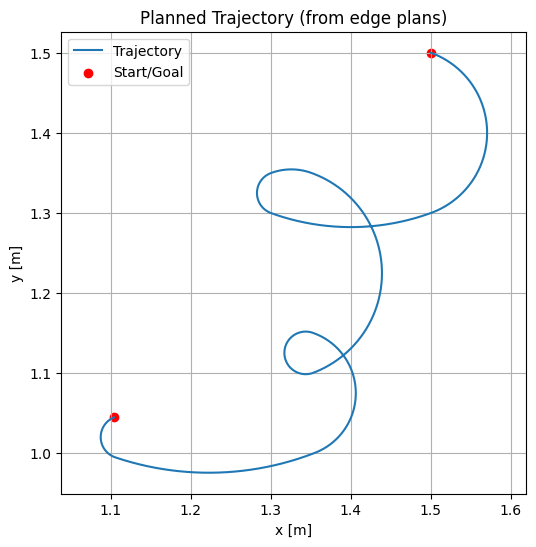

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_plan(start_pose, plan):
    """
    Simulate the trajectory given a start pose (FriendlyPose) and a plan (list of PlanStep).
    Returns arrays of x, y, theta.
    """
    x, y, theta_deg = start_pose.x, start_pose.y, start_pose.theta_deg
    xs, ys, thetas = [x], [y], [theta_deg]
    for step in plan:
        duration = step.duration
        v = step.velocity_x_m_s
        w_deg = step.angular_velocity_deg_s
        w = np.deg2rad(w_deg)
        theta = np.deg2rad(theta_deg)
        dt = 0.001
        n = max(1, int(duration / dt))
        for _ in range(n):
            if abs(w) < 1e-6:
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
            else:
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
                theta += w * dt
            xs.append(x)
            ys.append(y)
            thetas.append(np.rad2deg(theta))
        theta_deg = np.rad2deg(theta)
    return np.array(xs), np.array(ys), np.array(thetas)

def node_to_pose(node):
    # Converts (x, y, theta) in centimeters/degrees to FriendlyPose in meters/degrees
    return FriendlyPose(x=node[0]/100.0, y=node[1]/100.0, theta_deg=node[2])

def plot_trajectory_from_path(plan, path):
    """
    Plots the continuous trajectory defined by the plans on the edges of the path.
    """
    all_xs, all_ys = [], []
    start_node = path[0]
    start_pose = node_to_pose(start_node)
    xs, ys, _ = simulate_plan(start_pose, plan)
    if i > 0:
        # Avoid duplicating the first point of each segment
        xs = xs[1:]
        ys = ys[1:]
    all_xs.extend(xs)
    all_ys.extend(ys)
    plt.figure(figsize=(6,6))
    plt.plot(all_xs, all_ys, label="Trajectory")
    plt.scatter([all_xs[0], all_xs[-1]], [all_ys[0], all_ys[-1]], c='red', label="Start/Goal")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title("Planned Trajectory (from edge plans)")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()
    
plot_trajectory_from_path(plan, path)